# Ensambles: Random Forest

# Librerías

mglearn es una librería de apoyo, creada para el libro [Introduction to Machine Learning with Python](https://github.com/amueller/introduction_to_ml_with_python)


In [249]:
! pip install mglearn;
import mglearn
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [168]:
def print_metrics(y, pred, av='binary'):
  accuracy = accuracy_score(y, pred)
  precision = precision_score(y, pred, average=av)
  recall = recall_score(y, pred, average=av)
  f1 = f1_score(y, pred, average=av)
  confusion = confusion_matrix(y, pred)
  print(f'Accuracy: {accuracy:.2f},\n\nPrecision: {precision:.2f}')
  print(f'\nRecall: {recall:.2f},\n\nF1: {f1:.2f}')
  print(f'\nMatriz de confusión:\n{confusion}\n')

# Dataset

In [191]:
X, y = make_moons(n_samples=100, noise=0.3, random_state=53)
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.2)

fig = px.scatter(x=X[:, 0], y=X[:, 1], color=y.astype(np.ubyte),
                 title="Make moons", width=700, height=500)
fig.update_layout(legend_title_text='Clases')

# Repaso: Árboles de Decisión
https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html

[Text(0.5, 0.875, 'x2 <= -0.047\ngini = 0.5\nsamples = 80\nvalue = [41, 39]\nclass = C1'),
 Text(0.2, 0.625, 'x1 <= -0.533\ngini = 0.153\nsamples = 24\nvalue = [2, 22]\nclass = C2'),
 Text(0.35, 0.75, 'True  '),
 Text(0.1, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = C1'),
 Text(0.3, 0.375, 'x1 <= 1.193\ngini = 0.083\nsamples = 23\nvalue = [1, 22]\nclass = C2'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 17\nvalue = [0, 17]\nclass = C2'),
 Text(0.4, 0.125, 'gini = 0.278\nsamples = 6\nvalue = [1, 5]\nclass = C2'),
 Text(0.8, 0.625, 'x1 <= 1.497\ngini = 0.423\nsamples = 56\nvalue = [39, 17]\nclass = C1'),
 Text(0.65, 0.75, '  False'),
 Text(0.7, 0.375, 'x1 <= -0.558\ngini = 0.305\nsamples = 48\nvalue = [39, 9]\nclass = C1'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]\nclass = C1'),
 Text(0.8, 0.125, 'gini = 0.368\nsamples = 37\nvalue = [28, 9]\nclass = C1'),
 Text(0.9, 0.375, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]\nclass = C2')]

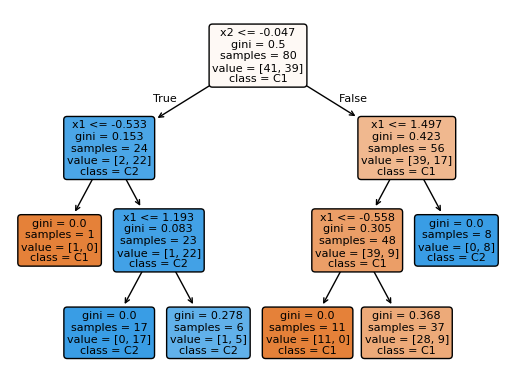

In [192]:
arbol = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xtrn,ytrn)
plot_tree(arbol, feature_names=("x1","x2"), class_names=("C1","C2"),fontsize=8,
          filled=True,rounded=True)

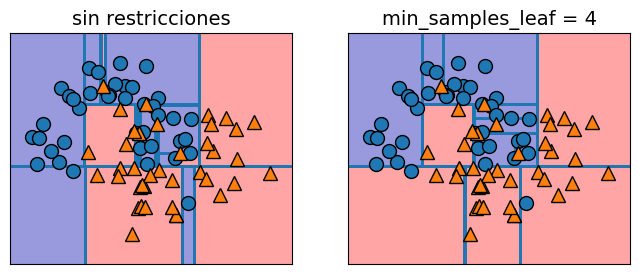

In [193]:
arb1 = DecisionTreeClassifier(random_state=0).fit(Xtrn, ytrn)
arb2 = DecisionTreeClassifier(min_samples_leaf=4, random_state=0)
arb2.fit(Xtrn, ytrn)

# Gráfica de los límites de decisión
fig, axes = plt.subplots(ncols=2, figsize=(8, 3), sharey=True)
plt.sca(axes[0])
mglearn.plots.plot_tree_partition(Xtrn,ytrn,arb1)
plt.title("sin restricciones", fontsize=14)
plt.sca(axes[1])
mglearn.plots.plot_tree_partition(Xtrn,ytrn,arb2)
plt.title("min_samples_leaf = {}".format(arb2.min_samples_leaf), fontsize=14)
plt.ylabel("")

plt.show()

In [194]:
print('Arbol 1:')
print_metrics(ytst, arb1.predict(Xtst))
print('Arbol 2:')
print_metrics(ytst, arb1.predict(Xtst))

Arbol 1:
Accuracy: 0.90,

Precision: 0.91

Recall: 0.91,

F1: 0.91

Matriz de confusión:
[[ 8  1]
 [ 1 10]]

Arbol 2:
Accuracy: 0.90,

Precision: 0.91

Recall: 0.91,

F1: 0.91

Matriz de confusión:
[[ 8  1]
 [ 1 10]]



# Random forest
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [240]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=5, max_features='sqrt',
                                random_state=0).fit(Xtrn,ytrn)

y_pred_rf = rf_clf.predict(Xtst)
print('Random Forest')
print_metrics(ytst, y_pred_rf)

Random Forest
Accuracy: 0.80,

Precision: 1.00

Recall: 0.64,

F1: 0.78

Matriz de confusión:
[[9 0]
 [4 7]]



## Límites de decisión

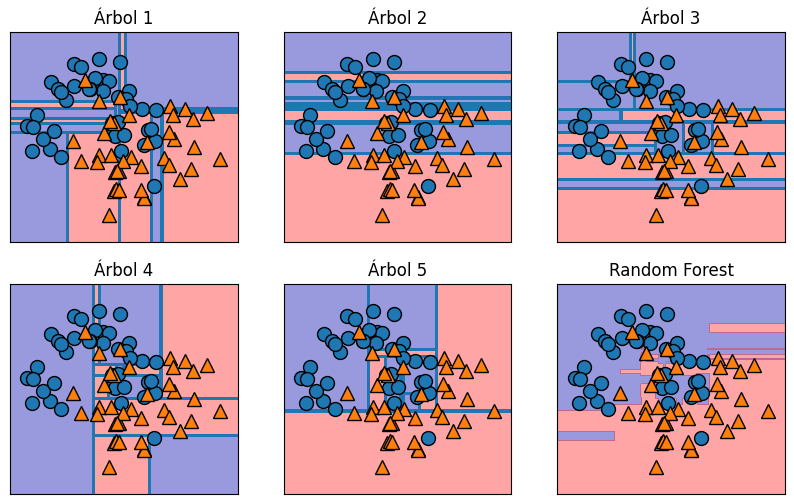

In [239]:
fig, axes = plt.subplots(2,3, figsize=(10,6))
# Gráfica de árboles
for i, (ax,arb) in enumerate(zip(axes.ravel(),rf_clf.estimators_)):
    ax.set_title("Árbol {}".format(i+1))
    mglearn.plots.plot_tree_partition(Xtrn,ytrn,arb,ax=ax);

# Gráfica de Random Forest
mglearn.plots.plot_2d_separator(rf_clf, Xtrn, fill=True, ax=axes[-1,-1],
                                alpha = 0.4);
mglearn.discrete_scatter(Xtrn[:,0],Xtrn[:,1],ytrn);
axes[-1,-1].set_title("Random Forest");

Random Forest es equivalente a un ensamble de árboles de decisión con el [algoritmo Bagging](https://scikit-learn.org/1.5/modules/generated/sklearn.ensemble.BaggingClassifier.html)

In [241]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features='sqrt', random_state=0),
    n_estimators=5, random_state=0)
bag_clf.fit(Xtrn, ytrn)

y_pred_bag = bag_clf.predict(Xtst)


print('Algoritmo Bagging')
print_metrics(ytst, y_pred_bag)

Algoritmo Bagging
Accuracy: 0.90,

Precision: 1.00

Recall: 0.82,

F1: 0.90

Matriz de confusión:
[[9 0]
 [2 9]]



In [238]:
# Comparación
table = pd.DataFrame({'RF':y_pred_rf, 'Bag':y_pred_bag})
print(table)

    RF  Bag
0    1    1
1    0    0
2    1    1
3    0    0
4    0    1
5    1    1
6    1    1
7    0    0
8    1    1
9    0    0
10   0    0
11   1    1
12   0    0
13   0    0
14   0    0
15   1    1
16   0    0
17   0    0
18   0    1
19   0    0


## Optimización de parámetros
* n_estimators: Número de árboles en el bosque. Aumentar este valor
generalmente mejora el rendimiento del modelo, pero también aumenta el costo computacional.

* max_depth: La profundidad máxima de los árboles. Limitar la profundidad ayuda
a prevenir el sobreajuste.

* min_samples_split: El número mínimo de muestras requeridas para dividir un
nodo interno.

* min_samples_leaf: El número mínimo de muestras requeridas para estar en un
nodo hoja.

* max_leaf_nodes: número máximo de nodos terminales

In [257]:
# Definición de un modelo clasificador de Random Forest
rf_clf = RandomForestClassifier(random_state=0)

# Definir los hiperparámetros a ajustar y sus posibles valores
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_leaf_nodes': [3, 5, 7]
}

# Configurar la búsqueda grid con validación cruzada (cross-validation)
grid_search = GridSearchCV(estimator=rf_clf, param_grid=param_grid,
                           cv=5, scoring='accuracy')

# Realizar la búsqueda grid en el conjunto de entrenamiento
grid_search.fit(Xtrn, ytrn)

# Obtener los mejores hiperparámetros encontrados
best_params = grid_search.best_params_
print('Mejores hiperparámetros:', best_params)

# Utilizar el modelo con los mejores hiperparámetros para hacer predicciones
# en el conjunto de prueba
best_rf_classifier = grid_search.best_estimator_
y_pred_GS = best_rf_classifier.predict(Xtst)
# Evaluar el rendimiento del modelo con los mejores hiperparámetros
accuracy = accuracy_score(ytst, y_pred_GS)
print(f'Accuracy con mejores hiperparámetros: {accuracy:.2f}')

Mejores hiperparámetros: {'max_depth': None, 'max_leaf_nodes': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy con mejores hiperparámetros: 0.80


In [258]:
print('Métricas:')
print_metrics(ytst, y_pred_GS)

Métricas:
Accuracy: 0.80,

Precision: 1.00

Recall: 0.64,

F1: 0.78

Matriz de confusión:
[[9 0]
 [4 7]]



## Importancia de las características

In [242]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)
for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
    print(round(score, 2), name)

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)


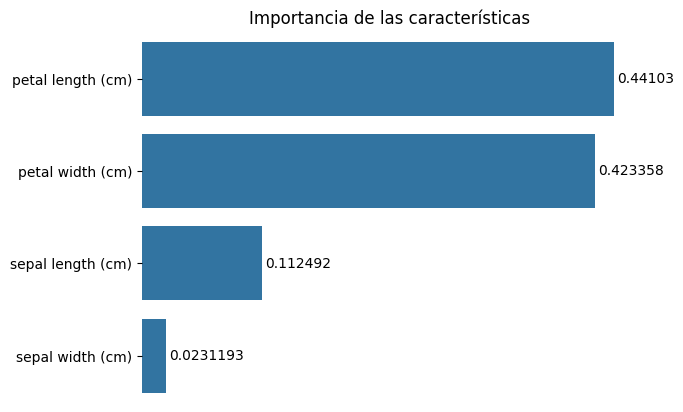

In [254]:
#Creo un df con dos columnas: características e importancias
features_df = pd.DataFrame({'features': iris.data.columns,
                            'importances': rnd_clf.feature_importances_ })

# Ordeno en base a la importancia
features_df_sorted = features_df.sort_values(by='importances', ascending=False)

g = sns.barplot(data=features_df_sorted, x='importances', y ='features')
sns.despine(bottom = True, left = True)
g.set_title('Importancia de las características')
g.set(xlabel=None, ylabel=None, xticks=[])
for value in g.containers:
    g.bar_label(value, padding=2)